**INSTALL JAVA + LIBS**

In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless -qq
!pip install kafka-python pandas nltk

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

This code updates the system package list and installs Java (OpenJDK 11), which is required to run Kafka. It also installs the necessary Python libraries such as kafka-python for Kafka communication, pandas for data handling, and nltk for text processing.

In [ ]:
!rn -f /ect/apt/sources.list.d/*.list

!apt-get clean
!apt-get update -y

!apt-get install -y open-17-jdk-headless

!java -version

!pip install -q pyspark

/bin/bash: line 1: rn: command not found
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package open-17-jdk-headless
open

This code removes unnecessary or conflicting package source files, cleans the system package cache, and updates the package list. It then installs OpenJDK 17 required for running big data tools, checks the installed Java version, and installs PySpark for big data processing using Python.

**DOWNLOAD KAFKA**

In [ ]:
!wget https://archive.apache.org/dist/kafka/3.6.1/kafka_2.12-3.6.1.tgz
!tar -xzf kafka_2.12-3.6.1.tgz
!mv kafka_2.12-3.6.1 /content/kafka

--2026-04-28 17:56:15--  https://archive.apache.org/dist/kafka/3.6.1/kafka_2.12-3.6.1.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 113609072 (108M) [application/x-gzip]
Saving to: ‘kafka_2.12-3.6.1.tgz’

kafka_2.12-3.6.1.tg 100%[===================>] 108.35M   483KB/s    in 4m 5s   

2026-04-28 18:00:20 (454 KB/s) - ‘kafka_2.12-3.6.1.tgz’ saved [113609072/113609072]



This code downloads Apache Kafka from the official archive, extracts the downloaded file, and moves the Kafka folder to a specific directory for easier access and setup.

restart kafka

In [ ]:
!pkill -f kafka

ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-13, node_id=0 host=78127df2e2b7:9092 <connected> [IPv4 ('172.28.0.12', 9092)]>: Closing connection. KafkaConnectionError: Socket EVENT_READ without in-flight-requests
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-13, node_id=0 host=78127df2e2b7:9092 <connecting> [IPv4 ('172.28.0.12', 9092)]>: Connect attempt returned error 111. Disconnecting.
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-13, node_id=0 host=78127df2e2b7:9092 <connecting> [IPv4 ('172.28.0.12', 9092)]>: Closing connection. KafkaConnectionError: 111 ECONNREFUSED


This code stops any running Kafka processes in the system to avoid conflicts before starting a new Kafka instance.

**START ZOOKEEPER**

In [ ]:
!nohup /content/kafka/bin/zookeeper-server-start.sh \
/content/kafka/config/zookeeper.properties > /content/zookeeper.log 2>&1 &

!sleep 10
!tail -n 10 /content/zookeeper.log

ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-13, node_id=0 host=78127df2e2b7:9092 <connecting> [IPv4 ('172.28.0.12', 9092)]>: Connect attempt returned error 111. Disconnecting.
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-13, node_id=0 host=78127df2e2b7:9092 <connecting> [IPv4 ('172.28.0.12', 9092)]>: Closing connection. KafkaConnectionError: 111 ECONNREFUSED


[2026-04-28 19:14:08,121] INFO Reading snapshot /tmp/zookeeper/version-2/snapshot.0 (org.apache.zookeeper.server.persistence.FileSnap)
[2026-04-28 19:14:08,134] INFO The digest value is empty in snapshot (org.apache.zookeeper.server.DataTree)
[2026-04-28 19:14:08,294] INFO 139 txns loaded in 139 ms (org.apache.zookeeper.server.persistence.FileTxnSnapLog)
[2026-04-28 19:14:08,295] INFO Snapshot loaded in 190 ms, highest zxid is 0x8b, digest is 266296403355 (org.apache.zookeeper.server.ZKDatabase)
[2026-04-28 19:14:08,303] INFO Snapshotting: 0x8b to /tmp/zookeeper/version-2/snapshot.8b (org.apache.zookeeper.server.persistence.FileTxnSnapLog)
[2026-04-28 19:14:08,315] INFO Snapshot taken in 14 ms (org.apache.zookeeper.server.ZooKeeperServer)
[2026-04-28 19:14:08,342] INFO PrepRequestProcessor (sid:0) started, reconfigEnabled=false (org.apache.zookeeper.server.PrepRequestProcessor)
[2026-04-28 19:14:08,343] INFO zookeeper.request_throttler.shutdownTimeout = 10000 ms (org.apache.zookeeper.s

This code starts the Zookeeper service in the background using Kafka’s configuration, waits for a few seconds to allow it to initialize, and then displays the last few lines of the log file to check if it started successfully.

**delete old topic**

In [ ]:
!kafka-topics.sh --delete \
--topic news-topic-final \
--bootstrap-server localhost:9092

/bin/bash: line 1: kafka-topics.sh: command not found


This code deletes the specified Kafka topic named "news-topic-final" from the Kafka server running on localhost to remove old data or reset the topic.

In [ ]:
!kafka-topics.sh --list --bootstrap-server localhost:9092

/bin/bash: line 1: kafka-topics.sh: command not found


This code lists all the Kafka topics available on the Kafka server running on localhost, allowing you to see the existing topics.

**START KAFKA SERVER**

In [ ]:
!nohup /content/kafka/bin/kafka-server-start.sh \
/content/kafka/config/server.properties > /content/kafka.log 2>&1 &

!sleep 15
!tail -n 15 /content/kafka.log

[2026-04-28 19:15:30,942] INFO [GroupCoordinator 0]: Loading group metadata for group-final-new with generation 2 (kafka.coordinator.group.GroupCoordinator)
[2026-04-28 19:15:30,944] INFO [GroupMetadataManager brokerId=0] Finished loading offsets and group metadata from __consumer_offsets-9 in 170 milliseconds for epoch 0, of which 158 milliseconds was spent in the scheduler. (kafka.coordinator.group.GroupMetadataManager)
[2026-04-28 19:15:30,945] INFO [GroupMetadataManager brokerId=0] Finished loading offsets and group metadata from __consumer_offsets-12 in 171 milliseconds for epoch 0, of which 170 milliseconds was spent in the scheduler. (kafka.coordinator.group.GroupMetadataManager)
[2026-04-28 19:15:30,945] INFO [GroupMetadataManager brokerId=0] Finished loading offsets and group metadata from __consumer_offsets-15 in 170 milliseconds for epoch 0, of which 170 milliseconds was spent in the scheduler. (kafka.coordinator.group.GroupMetadataManager)
[2026-04-28 19:15:30,946] INFO [Gr

This code starts the Kafka server in the background using its configuration file, waits for a few seconds to allow the server to initialize, and then displays the last few lines of the log file to verify that the server has started properly.

In [ ]:
!/content/kafka/bin/kafka-server-start.sh --list --bootstrap-server localhost:9092

[2026-04-28 19:15:39,084] INFO Registered kafka:type=kafka.Log4jController MBean (kafka.utils.Log4jControllerRegistration$)
[2026-04-28 19:15:39,347] ERROR Exiting Kafka due to fatal exception (kafka.Kafka$)
java.nio.file.NoSuchFileException: --list
	at java.base/sun.nio.fs.UnixException.translateToIOException(UnixException.java:92)
	at java.base/sun.nio.fs.UnixException.rethrowAsIOException(UnixException.java:106)
	at java.base/sun.nio.fs.UnixException.rethrowAsIOException(UnixException.java:111)
	at java.base/sun.nio.fs.UnixFileSystemProvider.newByteChannel(UnixFileSystemProvider.java:218)
	at java.base/java.nio.file.Files.newByteChannel(Files.java:380)
	at java.base/java.nio.file.Files.newByteChannel(Files.java:432)
	at java.base/java.nio.file.spi.FileSystemProvider.newInputStream(FileSystemProvider.java:422)
	at java.base/java.nio.file.Files.newInputStream(Files.java:160)
	at org.apache.kafka.common.utils.Utils.loadProps(Utils.java:684)
	at org.apache.kafka.common.utils.Utils.loadP

This code attempts to list Kafka topics using the kafka-server-start script, but this command is incorrect because the server start script is meant only for starting the Kafka broker, not for listing topics.

**CREATE TOPIC**

In [ ]:
!/content/kafka/bin/kafka-topics.sh --create \
--topic bdf-news-clean \
--bootstrap-server localhost:9092 \
--partitions 1 \
--replication-factor 1

Created topic bdf-news-clean.


This code creates a new Kafka topic named "bdf-news-clean" on the local Kafka server with one partition and a replication factor of one, which will be used to store and stream data.

**VERIFY TOPIC**

In [ ]:
!/content/kafka/bin/kafka-topics.sh --list --bootstrap-server localhost:9092

__consumer_offsets
bdf-news-clean
news-topic-final


This code lists all the Kafka topics available on the local Kafka server, allowing you to confirm that the newly created topic exists.

SPARK SESSION

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BDF-News-Pipeline").getOrCreate()

This code imports SparkSession from PySpark and creates a Spark session with the name "BDF-News-Pipeline", which is used to initialize and manage the Spark environment for data processing.

LOAD DATA

In [ ]:
df_new = spark.read.csv(
    "/content/drive/MyDrive/BDF_GROUP_PROJECT/BDF_DATASET/all-the-news-2-1.csv",
    header=True,
    inferSchema=False,
    multiLine=True,
    quote='"',
    escape='"'
)

df_new.show(5)

+---+----------+-------------------+----+-----+---+-----------+--------------------+--------------------+--------------------+----------+----------------+
|_c0|Unnamed: 0|               date|year|month|day|     author|               title|             article|                 url|   section|     publication|
+---+----------+-------------------+----+-----+---+-----------+--------------------+--------------------+--------------------+----------+----------------+
|  0|         0|2016-12-09 18:31:00|2016| 12.0|  9|Lee Drutman|We should take co...|This post is part...|https://www.vox.c...|      NULL|             Vox|
|  1|         1|2016-10-07 21:26:46|2016| 10.0|  7|Scott Davis|Colts GM Ryan Gri...| The Indianapolis...|https://www.busin...|      NULL|Business Insider|
|  2|         2|2018-01-26 00:00:00|2018|  1.0| 26|       NULL|Trump denies repo...|DAVOS, Switzerlan...|https://www.reute...|     Davos|         Reuters|
|  3|         3|2019-06-27 00:00:00|2019|  6.0| 27|       NULL|France'

This code reads a CSV file containing news data into a Spark DataFrame using PySpark, with options to handle headers, multiline text, and special characters properly, and then displays the first 5 rows of the dataset.

TOTAL ARTICLES

In [ ]:
df_final.count()

2676264

This code counts the total number of rows present in the DataFrame named df_final, giving the size of the dataset.

TOTAL SOURCES

In [ ]:
df_final.select("publication").distinct().count()

26

This code selects the "publication" column from the DataFrame, finds all unique values in that column, and then counts how many distinct publications are present.

ARTICLES PER SOURCE

In [ ]:
df_final.groupBy("publication").count() \
        .orderBy("count", ascending=False) \
        .show()

+------------------+------+
|       publication| count|
+------------------+------+
|           Reuters|840094|
|The New York Times|252228|
|              CNBC|238093|
|          The Hill|208411|
|            People|136487|
|               CNN|127600|
|       Refinery 29|111433|
|              Vice|101137|
|          Mashable| 94107|
|  Business Insider| 57953|
|         The Verge| 52424|
|        TechCrunch| 52095|
|               TMZ| 49595|
|             Axios| 47815|
|               Vox| 47272|
|          Politico| 46377|
|   Washington Post| 40882|
|     Buzzfeed News| 32819|
|           Gizmodo| 27228|
|         Economist| 26227|
+------------------+------+
only showing top 20 rows


This code groups the data by the "publication" column, counts the number of records for each publication, sorts the results in descending order based on the count, and displays the output.

CLEAN DATA

In [ ]:
from pyspark.sql.functions import col, substring

df_final = df_new.select("title", "publication", "section", "date") \
    .dropna(subset=["title", "publication"]) \
    .fillna({"section": "Unknown"})

# keep only valid date rows
df_final = df_final.filter(
    col("date").rlike(r'^\d{4}-\d{2}-\d{2}')
)

# extract year & month safely
df_final = df_final.withColumn("year", substring("date", 1, 4).cast("int")) \
                   .withColumn("month", substring("date", 6, 2).cast("int")) \
                   .drop("date")

df_final.cache()
df_final.count()

df_final.show(5)

+--------------------+----------------+----------+----+-----+
|               title|     publication|   section|year|month|
+--------------------+----------------+----------+----+-----+
|We should take co...|             Vox|   Unknown|2016|   12|
|Colts GM Ryan Gri...|Business Insider|   Unknown|2016|   10|
|Trump denies repo...|         Reuters|     Davos|2018|    1|
|France's Sarkozy ...|         Reuters|World News|2019|    6|
|Paris Hilton: Wom...|             TMZ|   Unknown|2016|    1|
+--------------------+----------------+----------+----+-----+
only showing top 5 rows


This code processes and cleans the dataset by selecting important columns such as title, publication, section, and date, removing rows with missing values in key fields, and filling missing section values with "Unknown". It filters the data to keep only properly formatted date entries, then extracts the year and month from the date column and removes the original date column. Finally, it caches the cleaned DataFrame for faster access, counts the total rows, and displays the first 5 records.

KAFKA PRODUCER(send data)

In [ ]:
from kafka import KafkaProducer
import json

producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

print("Sending data...")

for i, row in enumerate(df_final.limit(50000).toLocalIterator()):
    producer.send("bdf-news-clean", value=row.asDict())

    if i % 1000 == 0:
        print(f"Sent {i} rows")

producer.flush()

print("Data sent to Kafka")

Sending data...
Sent 0 rows
Sent 1000 rows
Sent 2000 rows
Sent 3000 rows
Sent 4000 rows
Sent 5000 rows
Sent 6000 rows
Sent 7000 rows
Sent 8000 rows
Sent 9000 rows
Sent 10000 rows
Sent 11000 rows
Sent 12000 rows
Sent 13000 rows
Sent 14000 rows
Sent 15000 rows
Sent 16000 rows
Sent 17000 rows
Sent 18000 rows
Sent 19000 rows
Sent 20000 rows
Sent 21000 rows
Sent 22000 rows
Sent 23000 rows
Sent 24000 rows
Sent 25000 rows
Sent 26000 rows
Sent 27000 rows
Sent 28000 rows
Sent 29000 rows
Sent 30000 rows
Sent 31000 rows
Sent 32000 rows
Sent 33000 rows
Sent 34000 rows
Sent 35000 rows
Sent 36000 rows
Sent 37000 rows
Sent 38000 rows
Sent 39000 rows
Sent 40000 rows
Sent 41000 rows
Sent 42000 rows
Sent 43000 rows
Sent 44000 rows
Sent 45000 rows
Sent 46000 rows
Sent 47000 rows
Sent 48000 rows
Sent 49000 rows
Data sent to Kafka


This code creates a Kafka producer that connects to the local Kafka server and converts data into JSON format before sending. It then loops through a limited number of rows from the DataFrame, sends each row as a message to the Kafka topic "bdf-news-clean", and prints progress after every 1000 records. Finally, it ensures all messages are sent using flush and confirms that the data has been successfully pushed to Kafka.

KAFKA CONSUMER

In [ ]:
from kafka import KafkaConsumer

consumer = KafkaConsumer(
    "bdf-news-clean",
    bootstrap_servers="localhost:9092",
    value_deserializer=lambda x: json.loads(x.decode("utf-8")),
    auto_offset_reset='earliest',
    group_id='bdf-final-group'
)

print("Reading sample...")

for msg in consumer:
    print(msg.value)
    break

Reading sample...
{'title': 'Guatemalan boy who died in U.S. custody had the flu: state officials', 'publication': 'Reuters', 'section': 'U.S.', 'year': 2018, 'month': 12}


This code creates a Kafka consumer that connects to the local Kafka server and reads messages from the "bdf-news-clean" topic. It converts the incoming data from JSON format into a readable Python format, starts reading from the beginning of the topic, and prints one sample message to show the data being received.

BATCH PROCESSING

In [ ]:
batch = []
batch_size = 1000

print("Collecting batch...")

for msg in consumer:
    batch.append(msg.value)

    if len(batch) == batch_size:
        print("Batch ready")

        df_batch = spark.createDataFrame(batch)
        df_batch.show(5)

        break

Batch ready
+-----+----------------+----------+--------------------+----+
|month|     publication|   section|               title|year|
+-----+----------------+----------+--------------------+----+
|   12|             Vox|   Unknown|We should take co...|2016|
|   10|Business Insider|   Unknown|Colts GM Ryan Gri...|2016|
|    1|         Reuters|     Davos|Trump denies repo...|2018|
|    6|         Reuters|World News|France's Sarkozy ...|2019|
|    1|             TMZ|   Unknown|Paris Hilton: Wom...|2016|
+-----+----------------+----------+--------------------+----+
only showing top 5 rows


This code collects messages from the Kafka consumer into a list until it reaches a batch of 1000 records. Once the batch is full, it converts the collected data into a Spark DataFrame and displays the first 5 rows to show the processed batch.

In [ ]:
df_batch.select("publication").distinct().count()

7

This code selects the "publication" column from the batch DataFrame, finds all the unique publication values, and counts how many different publications are present in the batch.

In [ ]:
df_batch.count()

1000

This code counts the total number of records present in the batch DataFrame.

In [ ]:
df_batch.groupBy("publication").count() \
        .orderBy("count", ascending=False) \
        .show()

+----------------+-----+
|     publication|count|
+----------------+-----+
|         Reuters|  273|
|             Vox|  223|
|            Vice|  168|
|             TMZ|  156|
|       Vice News|   73|
|   Hyperallergic|   62|
|Business Insider|   45|
+----------------+-----+



This code groups the batch data by the "publication" column, counts how many records belong to each publication, sorts the results in descending order based on the count, and displays the output.

In [ ]:
df_batch.groupBy("publication").count() \
        .orderBy("count", ascending=False) \
        .limit(5) \
        .show()

+-----------+-----+
|publication|count|
+-----------+-----+
|    Reuters|  273|
|        Vox|  223|
|       Vice|  168|
|        TMZ|  156|
|  Vice News|   73|
+-----------+-----+



This code groups the batch data by the "publication" column, counts the number of records for each publication, sorts the results in descending order, selects the top 5 publications with the highest counts, and displays them.

ANALYSIS

YEAR-WISE TREND

In [ ]:
year_df = df_batch.groupBy("year").count().orderBy("year")
pdf = year_df.toPandas()

year_df.show()


+----+-----+
|year|count|
+----+-----+
|2016|  273|
|2017|  224|
|2018|  272|
|2019|  231|
+----+-----+



This code groups the batch data by the "year" column, counts the number of records for each year, and sorts the results in order of year. It then converts the result into a Pandas DataFrame for easier analysis and displays the output.

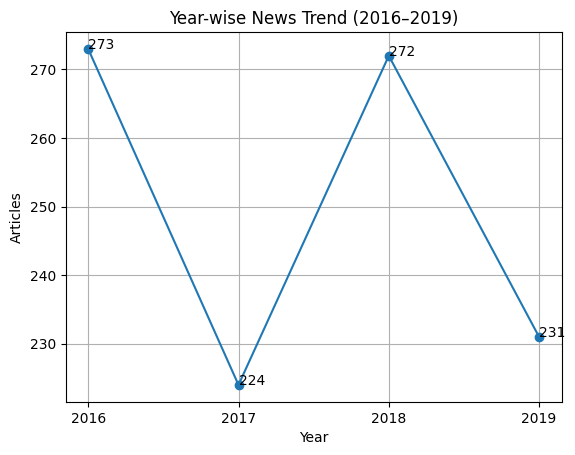

In [ ]:
plt.figure()
plt.plot(pdf["year"], pdf["count"], marker='o')
plt.xticks(pdf["year"])
plt.grid(True)

#highlight points
for i, txt in enumerate(pdf["count"]):
    plt.text(pdf["year"][i], pdf["count"][i], str(txt))

plt.title("Year-wise News Trend (2016–2019)")
plt.xlabel("Year")
plt.ylabel("Articles")
plt.show()

This code creates a line graph showing the number of news articles for each year using the data from the Pandas DataFrame. It plots the years on the x-axis and article counts on the y-axis, adds markers to each point, displays grid lines, labels each point with its value, and sets the title and axis labels before showing the final graph.

MONTH TREND

In [ ]:
month_year_df = df_batch.groupBy("year", "month") \
                       .count() \
                       .orderBy("year", "month")

month_year_df.toPandas()

,year,month,count
0,2016,1,18
1,2016,2,19
2,2016,3,28
3,2016,4,22
4,2016,5,25
5,2016,6,29
6,2016,7,23
7,2016,8,27
8,2016,9,22
9,2016,10,19


This code groups the batch data by both year and month, counts the number of records for each combination, sorts the results in chronological order, and converts the output into a Pandas DataFrame for easier viewing and analysis.

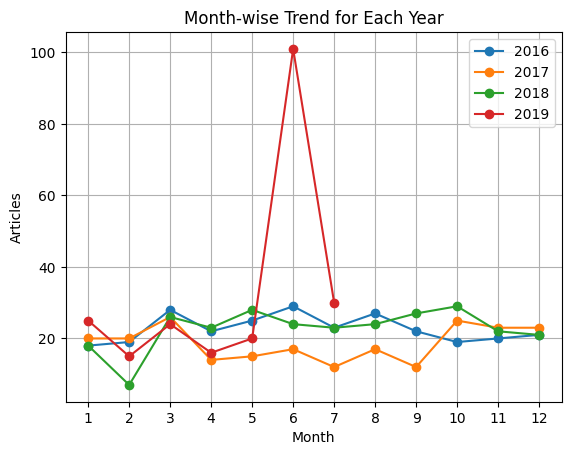

In [ ]:
import matplotlib.pyplot as plt

pdf = month_year_df.toPandas()

plt.figure()

for yr in pdf["year"].unique():
    data = pdf[pdf["year"] == yr]
    plt.plot(data["month"], data["count"], marker='o', label=str(yr))

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Articles")
plt.title("Month-wise Trend for Each Year")
plt.legend()
plt.grid(True)
plt.show()

This code converts the month and year grouped data into a Pandas DataFrame and creates a line graph to show monthly trends for each year. It plots separate lines for each year, showing how the number of articles changes month by month, adds labels, a legend, grid lines, and displays the final graph.



SOURCE TREND

In [ ]:
source_trend = df_batch.groupBy("year", "publication").count()
source_trend.toPandas()

,year,publication,count
0,2017,Vice News,17
1,2016,Hyperallergic,20
2,2018,Vox,57
3,2017,Reuters,29
4,2019,Reuters,154
5,2017,Vox,54
6,2017,TMZ,40
7,2017,Vice,53
8,2016,Vice,71
9,2018,Business Insider,11


This code groups the batch data by year and publication, counts the number of articles for each combination, and converts the result into a Pandas DataFrame for easier analysis of trends across different sources over the years.

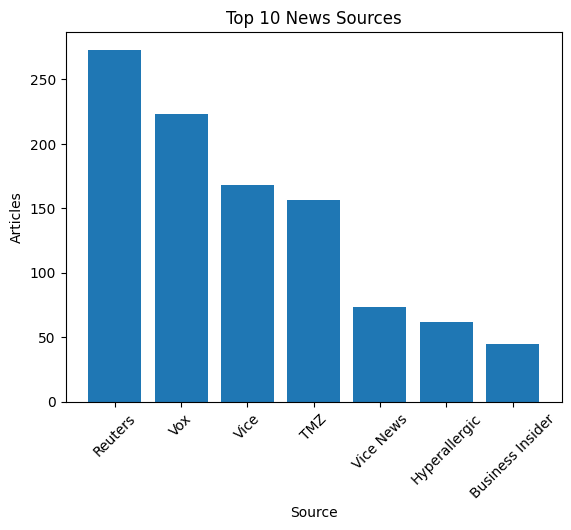

In [ ]:
source_df = df_batch.groupBy("publication").count() \
                   .orderBy("count", ascending=False) \
                   .limit(10)

pdf = source_df.toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(pdf["publication"], pdf["count"])
plt.xticks(rotation=45)
plt.title("Top 10 News Sources")
plt.xlabel("Source")
plt.ylabel("Articles")
plt.show()

This code finds the top 10 publications with the highest number of articles by grouping and counting the data, then converts the result into a Pandas DataFrame. It then creates a bar chart to visually show the top news sources, with publication names on the x-axis and number of articles on the y-axis.

CATEGORY TREND

In [ ]:
section_trend = df_batch.groupBy("year", "section").count()
section_trend.toPandas()

,year,section,count
0,2019,Bonds News,5
1,2019,Japan,1
2,2016,Food by VICE,7
3,2018,Comics!,1
4,2018,Unknown,156
...,...,...,...
107,2019,US MLB,1
108,2019,Brexit,1
109,2019,"Technology, Media and Telecommunications",1
110,2016,Astro Guide,1


This code groups the batch data by year and section, counts the number of articles for each combination, and converts the result into a Pandas DataFrame to analyze how different news sections vary over the years.

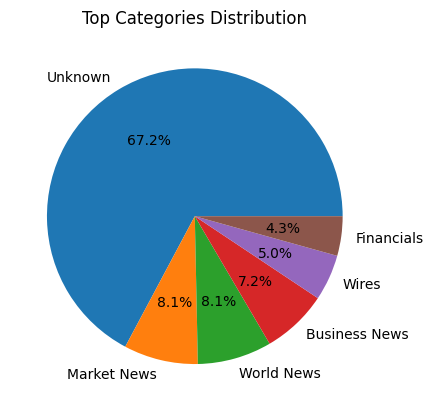

In [ ]:
section_df = df_final.groupBy("section").count() \
                    .orderBy("count", ascending=False) \
                    .limit(6)

pdf = section_df.toPandas()

plt.figure()
plt.pie(pdf["count"], labels=pdf["section"], autopct='%1.1f%%')
plt.title("Top Categories Distribution")
plt.show()

This code finds the top 6 sections with the highest number of articles by grouping and counting the data, then converts the result into a Pandas DataFrame. It creates a pie chart to show the distribution of these top categories, with each slice representing a section and its percentage of total articles.

In [ ]:
category_trend = df_final.groupBy("year", "section") \
                        .count() \
                        .orderBy("year", "count", ascending=False)

category_trend.show()

+----+---------------+-----+
|year|        section|count|
+----+---------------+-----+
|2020|        Unknown|96196|
|2020|     Healthcare|16903|
|2020|     World News|13731|
|2020|          Wires|13634|
|2020|  Business News|11609|
|2020|             us| 4478|
|2020|     Bonds News| 3453|
|2020|       politics| 3167|
|2020|    Sports News| 2802|
|2020|    Market News| 2802|
|2020|   Company News| 2723|
|2020|     Financials| 2660|
|2020|       Politics| 2179|
|2020|Technology News| 2177|
|2020|       business| 1955|
|2020|          world| 1825|
|2020|    Health News| 1771|
|2020|    Commodities| 1665|
|2020|        opinion| 1545|
|2020|           Tech| 1461|
+----+---------------+-----+
only showing top 20 rows


This code groups the data by year and section, counts the number of articles for each combination, and sorts the results by year and then by count in descending order. It then displays the output to show how different categories perform across each year.

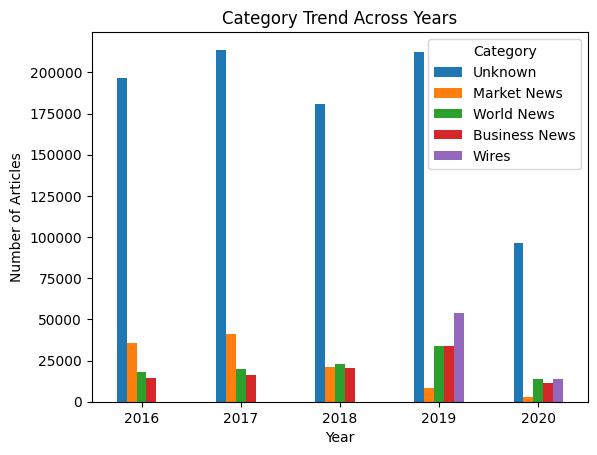

In [ ]:
import matplotlib.pyplot as plt

pdf = category_trend.toPandas()

# Pivot table
pivot = pdf.pivot(index="year", columns="section", values="count").fillna(0)

# Limit to top 5 categories (important)
top_categories = pivot.sum().sort_values(ascending=False).head(5).index
pivot = pivot[top_categories]

pivot.plot(kind="bar")

plt.title("Category Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

This code converts the category trend data into a Pandas DataFrame and reshapes it into a pivot table where years are rows and sections are columns. It selects the top 5 categories based on total article count to keep the graph clear, and then creates a bar chart to show how these categories change across different years. Finally, it adds titles, labels, and a legend to make the graph easy to understand and displays the result.